In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.inspection import DecisionBoundaryDisplay

sns.set(style="whitegrid")

In [9]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv("diabetes.csv")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(f"Zero counts before cleaning:\n{ (X[zero_cols] == 0).sum() }\n")

X[zero_cols] = X[zero_cols].replace(0, np.nan)
imputer = SimpleImputer(strategy='mean')
X[zero_cols] = imputer.fit_transform(X[zero_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete. Shape of training set:", X_train_scaled.shape)

Zero counts before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Data preprocessing complete. Shape of training set: (537, 8)


Linear SVM Accuracy (Scaled): 0.7273


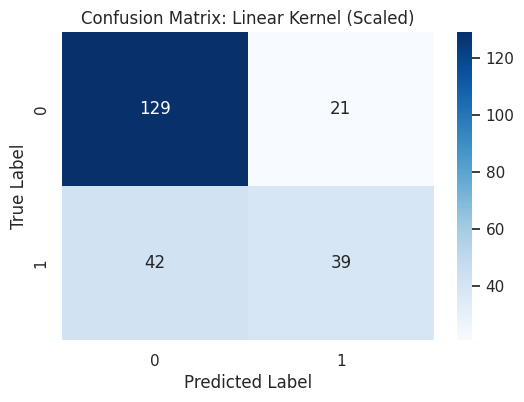

Linear SVM Accuracy (Unscaled): 0.7229
Impact of Scaling: 0.0043


In [10]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM Accuracy (Scaled): {acc_linear:.4f}")

cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Linear Kernel (Scaled)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

svm_unscaled = SVC(kernel='linear', random_state=42)
svm_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, svm_unscaled.predict(X_test))
print(f"Linear SVM Accuracy (Unscaled): {acc_unscaled:.4f}")
print(f"Impact of Scaling: {acc_linear - acc_unscaled:.4f}")


################################################################################
  OPTIMIZATION SCENARIO: MAXIMIZE ACCURACY
################################################################################
Testing Linear Kernel... Done.
Testing Rbf Kernel... Done.
Testing Poly Kernel... Done.


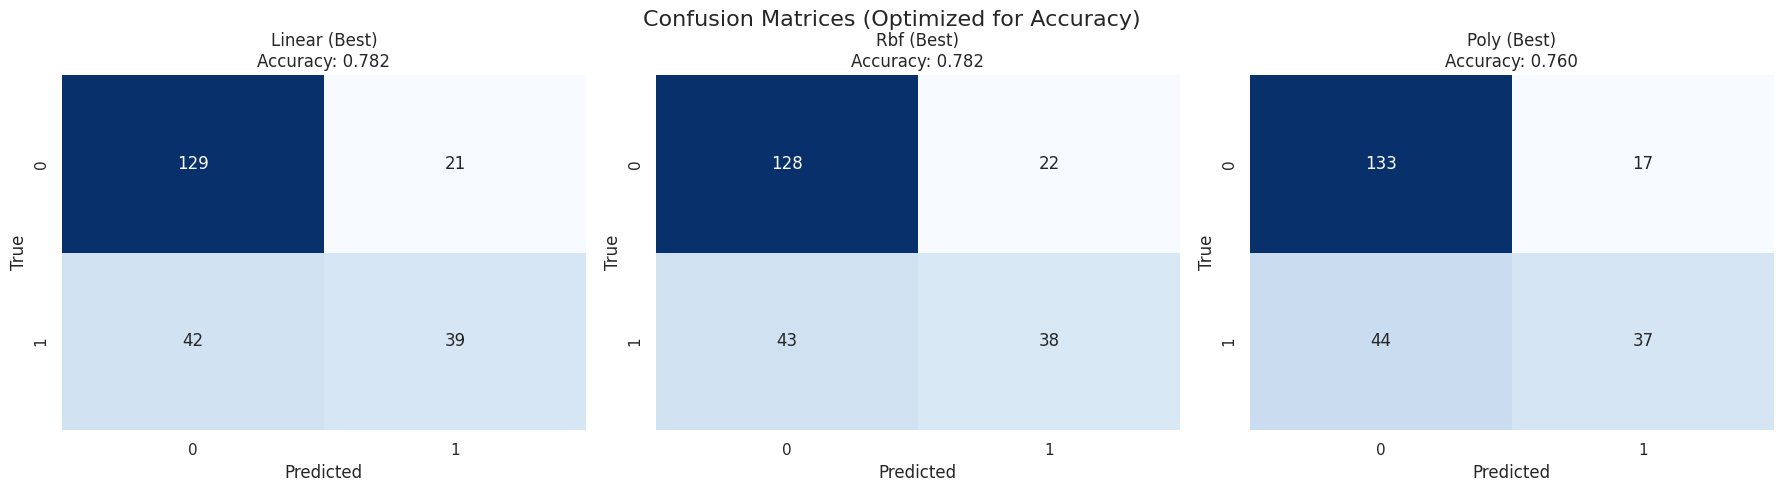


################################################################################
  OPTIMIZATION SCENARIO: MAXIMIZE F1
################################################################################
Testing Linear Kernel... Done.
Testing Rbf Kernel... Done.
Testing Poly Kernel... Done.


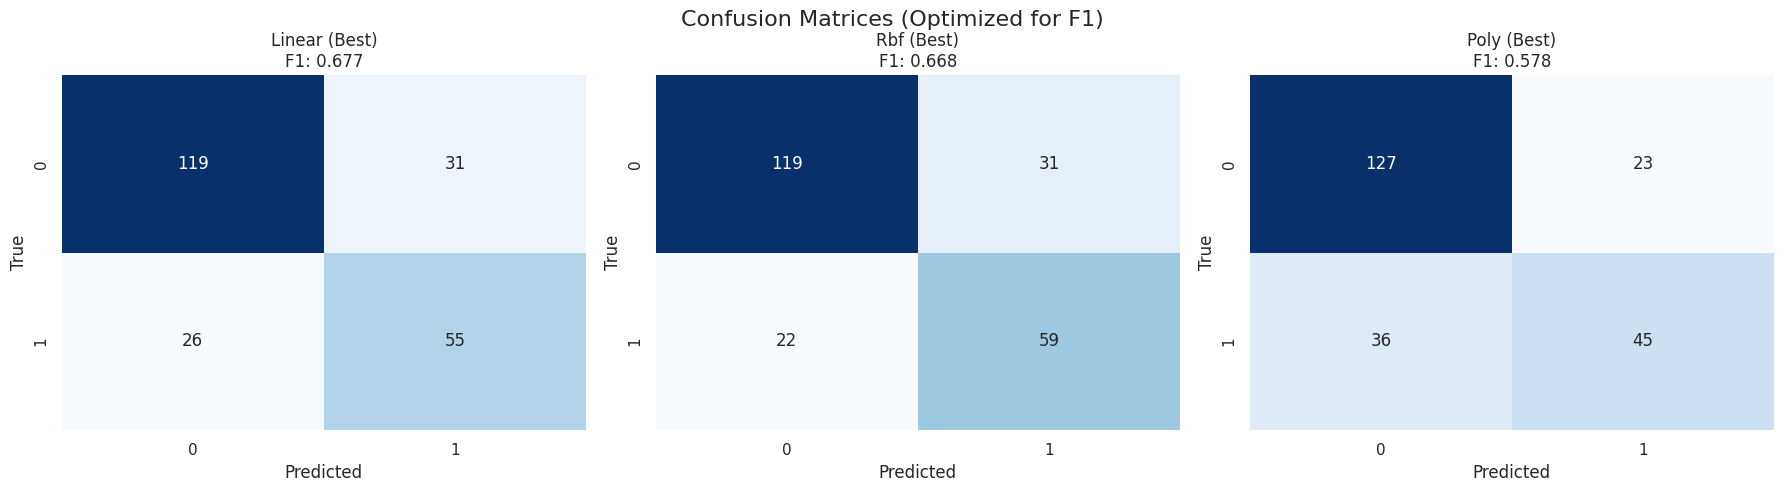


FINAL PERFORMANCE SUMMARY TABLE
     Target  Kernel  \
0  Accuracy  Linear   
1  Accuracy     Rbf   
2  Accuracy    Poly   
3        F1  Linear   
4        F1     Rbf   
5        F1    Poly   

                                                            Best Params  \
0                  {'C': 100, 'class_weight': None, 'kernel': 'linear'}   
1     {'C': 100, 'class_weight': None, 'gamma': 0.001, 'kernel': 'rbf'}   
2              {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'poly'}   
3            {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}   
4  {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}   
5                {'C': 1, 'class_weight': 'balanced', 'kernel': 'poly'}   

   Accuracy  Precision    Recall        F1  
0  0.727273   0.650000  0.481481  0.553191  
1  0.718615   0.633333  0.469136  0.539007  
2  0.735931   0.685185  0.456790  0.548148  
3  0.753247   0.639535  0.679012  0.658683  
4  0.770563   0.655556  0.728395  0.690058  
5  0.7445

In [11]:
kernel_grids = {
    'linear': {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    'rbf': {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1],
        'class_weight': [None, 'balanced']
    },
    'poly': {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'class_weight': [None, 'balanced']
    }
}

metrics_to_test = ['accuracy', 'f1']
final_results_data = []

for target_metric in metrics_to_test:
    print("\n" + "#" * 80)
    print(f"  OPTIMIZATION SCENARIO: MAXIMIZE {target_metric.upper()}")
    print("#" * 80)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Confusion Matrices (Optimized for {target_metric.capitalize()})", fontsize=16)

    for i, (kernel_name, p_grid) in enumerate(kernel_grids.items()):
        print(f"Testing {kernel_name.capitalize()} Kernel...", end=" ")

        grid = GridSearchCV(
            SVC(random_state=42),
            p_grid,
            cv=5,
            scoring=target_metric,
            n_jobs=-1
        )
        grid.fit(X_train_scaled, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print("Done.")

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d',
                    cmap='Blues', ax=axes[i], cbar=False)

        axes[i].set_title(
            f"{kernel_name.capitalize()} (Best)\n{target_metric.capitalize()}: {grid.best_score_:.3f}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")

        final_results_data.append({
            'Target Metric': target_metric.capitalize(),
            'Kernel': kernel_name.capitalize(),
            'Best Parameters': str(grid.best_params_),
            'Test Accuracy': acc,
            'Test Precision': prec,
            'Test Recall': rec,
            'Test F1-Score': f1
        })

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

summary_df = pd.DataFrame(final_results_data)

summary_df.columns = ['Target', 'Kernel', 'Best Params',
                      'Accuracy', 'Precision', 'Recall', 'F1']

print("\n" + "="*80)
print("FINAL PERFORMANCE SUMMARY TABLE")
print("="*80)

pd.set_option('display.max_colwidth', None)
print(summary_df)

In [12]:

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5,
                           scoring='accuracy', verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_acc_tuned = accuracy_score(y_test, best_model.predict(X_test_scaled))
print(f"Test Set Accuracy (Tuned): {test_acc_tuned:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 100, 'class_weight': None, 'gamma': 0.001, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.7820
Test Set Accuracy (Tuned): 0.7186


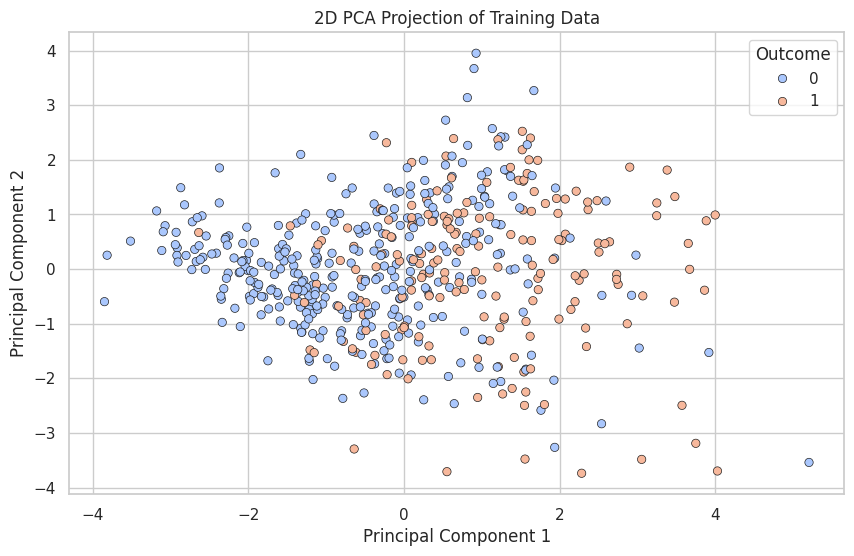

<Figure size 1000x600 with 0 Axes>

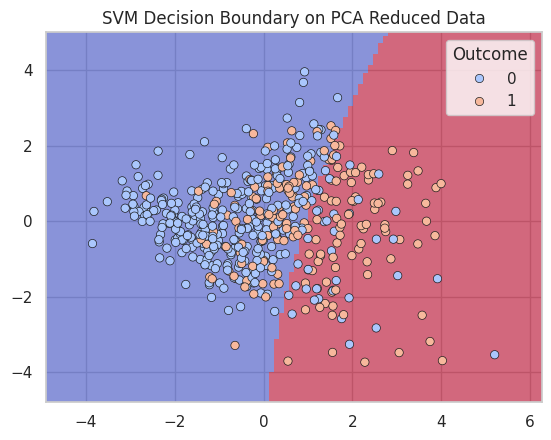

Accuracy on PCA-reduced data: 0.7229


In [13]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1],
                hue=y_train, palette='coolwarm', edgecolor='k')
plt.title("2D PCA Projection of Training Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

svm_pca = SVC(kernel='rbf', C=grid_search.best_params_[
              'C'], gamma=grid_search.best_params_['gamma'])
svm_pca.fit(X_train_pca, y_train)

plt.figure(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(
    svm_pca,
    X_train_pca,
    response_method="predict",
    cmap="coolwarm",
    plot_method="pcolormesh",
    shading="auto",
    alpha=0.6
)
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1],
                hue=y_train, palette='coolwarm', edgecolor='k')
plt.title("SVM Decision Boundary on PCA Reduced Data")
plt.show()

acc_pca = accuracy_score(y_test, svm_pca.predict(X_test_pca))
print(f"Accuracy on PCA-reduced data: {acc_pca:.4f}")

In [14]:
class_counts = y.value_counts()
print("Class distribution:\n", class_counts)

is_imbalanced = class_counts.min() / class_counts.max() < 0.5
print(
    f"\nIs dataset imbalanced? {'Yes' if class_counts[0] != class_counts[1] else 'No'}")

svm_balanced = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = svm_balanced.predict(X_test_scaled)
print("\n--- Standard SVM (RBF) Report ---")

svm_standard = SVC(kernel='rbf', random_state=42)
svm_standard.fit(X_train_scaled, y_train)
y_pred_standard = svm_standard.predict(X_test_scaled)

print(classification_report(y_test, y_pred_standard))

print("\n--- Balanced SVM (RBF) Report ---")
print(classification_report(y_test, y_pred_balanced))

rec_std = recall_score(y_test, y_pred_standard)
rec_bal = recall_score(y_test, y_pred_balanced)
print(f"Recall (Standard): {rec_std:.4f}")
print(f"Recall (Balanced): {rec_bal:.4f}")

Class distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64

Is dataset imbalanced? Yes

--- Standard SVM (RBF) Report ---
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       150
           1       0.68      0.49      0.57        81

    accuracy                           0.74       231
   macro avg       0.72      0.68      0.69       231
weighted avg       0.73      0.74      0.73       231


--- Balanced SVM (RBF) Report ---
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       150
           1       0.62      0.70      0.66        81

    accuracy                           0.74       231
   macro avg       0.72      0.74      0.73       231
weighted avg       0.75      0.74      0.75       231

Recall (Standard): 0.4938
Recall (Balanced): 0.7037
